#Import

In [ ]:
#Import base library
import numpy as np

import torch
import torch.nn as nn
from torch.autograd import Variable
# import random

#..and check a device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
print(device)

cuda:0


#Build Network

In [ ]:
#Try some activation functions: tanh, Swish(SiLU)
from math import tanh

#Structure of Swish function
class Swish(nn.Module):
    def __init__(self):
        super().__init__()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return  x* self.sigmoid(x)

#Activation function in this experiment
activation = nn.SiLU()
activation_ = nn.SiLU()

#Coefficient for solution PDE
k=1

In [ ]:
#Width of NN
M = 100


T = True
F = False

#Architecture of NN: 4 layers with M width, 3 input values and 1 output value
#NN for approximating u1 and u2
class Net_2D(nn.Module):
    def __init__(self):
        super(Net_2D, self).__init__()
        torch.manual_seed(1234) # Fix Initial_Parameter
        self.hidden_layer1 = nn.Linear(3,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer2 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer3 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer4 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        #self.hidden_layer5 = nn.Linear(M,M, bias = T)
        #torch.manual_seed(1234)
        self.output_layer = nn.Linear(M,1, bias = T)

    def forward(self, x,y,p):
        inputs = torch.cat([x,y,p],axis=1)
        layer1_out = activation(self.hidden_layer1(inputs))
        layer2_out = activation(self.hidden_layer2(layer1_out))
        layer3_out = activation(self.hidden_layer3(layer2_out))
        layer4_out = activation(self.hidden_layer4(layer3_out))
        #layer5_out = activation(self.hidden_layer5(layer4_out))
        output = self.output_layer(layer4_out)

        return output

#NN for approximating P
class Net_2D_f(nn.Module):
    def __init__(self):
        super(Net_2D_f, self).__init__()
        torch.manual_seed(1234) # Fix Initial_Parameter
        self.hidden_layer1 = nn.Linear(3,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer2 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer3 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer4 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        #self.hidden_layer5 = nn.Linear(M,M, bias = T)
        #torch.manual_seed(1234)
        self.output_layer = nn.Linear(M,1, bias = T)

    def forward(self, x,y,p):
        inputs = torch.cat([x,y,p],axis=1)
        layer1_out = activation_(self.hidden_layer1(inputs))
        layer2_out = activation_(self.hidden_layer2(layer1_out))
        layer3_out = activation_(self.hidden_layer3(layer2_out))
        layer4_out = activation_(self.hidden_layer4(layer3_out))
        #layer5_out = activation(self.hidden_layer5(layer4_out))
        output = self.output_layer(layer4_out)

        return output

In [ ]:
mse_cost_function = torch.nn.MSELoss() #MSE Function can be shared

#NN to approximate u1
net_2d_1 = Net_2D()
net_2d_1 = net_2d_1.to(device)

#NN to approximate u2
net_2d_2 = Net_2D()
net_2d_2 = net_2d_2.to(device)

#NN to approximate P
net_2d_P = Net_2D_f()
net_2d_P = net_2d_P.to(device)

#Optimizer: Adam, Learning rate: 0.001
optimizer1_h = torch.optim.Adam(net_2d_1.parameters(),lr=0.001)
optimizer2_h = torch.optim.Adam(net_2d_2.parameters(),lr=0.001)
optimizerP_h = torch.optim.Adam(net_2d_P.parameters(),lr=0.001)

#set PDE,residual

In [ ]:
def f3(x,y,p,x_bdy,y_bdy, f1,f2, net1, net2, netP):

    ##------------------------ Network output -------------------------------
    P = netP(x,y,p)
    w = net1(x,y,p)
    v = net2(x,y,p)

    w_bdy = net1(x_bdy,y_bdy,p)
    v_bdy = net2(x_bdy,y_bdy,p)

    ##--------------------Differentiation------------------------------------

    P_x = torch.autograd.grad(P.sum(), x, create_graph=True)[0]
    P_y = torch.autograd.grad(P.sum(), y, create_graph=True)[0]

    w_x = torch.autograd.grad(w.sum(), x, create_graph=True)[0]
    w_y = torch.autograd.grad(w.sum(), y, create_graph=True)[0]

    v_x = torch.autograd.grad(v.sum(), x, create_graph=True)[0]
    v_y = torch.autograd.grad(v.sum(), y, create_graph=True)[0]

    AbsDu = (w_x**2 + w_y**2 + v_x**2 + v_y**2)**((p-2)/2)

    div11 = torch.autograd.grad((AbsDu*w_x).sum(), x, create_graph=True)[0]
    div12 = torch.autograd.grad((AbsDu*w_y).sum(), y, create_graph=True)[0]
    div21 = torch.autograd.grad((AbsDu*v_x).sum(), x, create_graph=True)[0]
    div22 = torch.autograd.grad((AbsDu*v_y).sum(), y, create_graph=True)[0]

    ##-----------------------Calculate Variational----------------------------

    Integral = (P.mean())**2

    Bdy = (w_bdy**2 + v_bdy**2).mean()

    Var = ((1/p)*(w_x**2 + w_y**2 + v_x**2 + v_y**2)**(p/2) - (f1*w + f2*v)).mean()

    Div = ((w_x + v_y)**2).mean()

    gradP = ((P_x - f1 - div11 - div12)**2).mean() + ((P_y - f2 - div21 - div22)**2).mean()

    ##----------------------------Loss function-------------------------------

    return gradP + Var + Integral + 1000*Bdy + 1000*Div

#Set data point

In [ ]:
#Function to check if a point is inside the circle
def is_inside(x, y):

    return x**2 + y**2 < 1


#Generate random points inside the domain
def generate_random_points(n_points=1000):
    points = []
    while len(points) < n_points:
        x = np.random.uniform(-1, 1)
        y = np.random.uniform(-1, 1)
        if is_inside(x, y):
            points.append((x, y))
    return np.array(points)

#Example usage
random_points = generate_random_points(2000)

x_coords_ = random_points[:, 0].reshape(-1, 1)
y_coords_ = random_points[:, 1].reshape(-1, 1)
p_coords_ = (2*np.random.rand(len(x_coords_)) + 2).reshape(-1, 1)   #2 < p < 4

pt_x_collocation = Variable(torch.from_numpy(x_coords_).float(), requires_grad=True).to(device)
pt_y_collocation = Variable(torch.from_numpy(y_coords_).float(), requires_grad=True).to(device)
pt_p_collocation = Variable(torch.from_numpy(p_coords_).float(), requires_grad=True).to(device)

##-----------------------------set F-------------------------------------------------

pt_x = Variable(torch.from_numpy(x_coords_).float(), requires_grad=False).to(device)
pt_y = Variable(torch.from_numpy(y_coords_).float(), requires_grad=False).to(device)
pt_p = Variable(torch.from_numpy(p_coords_).float(), requires_grad=False).to(device)

pt_Q = k**(pt_p - 2)*(8*(pt_x**2)*(pt_y**2) + (1 - pt_x**2 - 3*(pt_y**2))**2 + (-1 + 3*(pt_x**2) + pt_y**2)**2)**((pt_p-2)/2)
pt_Q_x = k**(pt_p - 2)*((pt_p-2)/2*(8*(pt_x**2)*(pt_y**2) + (1 - pt_x**2 - 3*(pt_y**2))**2 + (-1 + 3*(pt_x**2) + pt_y**2)**2)**((pt_p-4)/2) * (16*(pt_x)*(pt_y**2) - 4*pt_x*(1 - pt_x**2 - 3*(pt_y**2)) + 12*pt_x*(-1 + 3*(pt_x**2) + pt_y**2)))
pt_Q_y = k**(pt_p - 2)*((pt_p-2)/2*(8*(pt_x**2)*(pt_y**2) + (1 - pt_x**2 - 3*(pt_y**2))**2 + (-1 + 3*(pt_x**2) + pt_y**2)**2)**((pt_p-4)/2) * (16*(pt_x**2)*(pt_y) - 12*pt_y*(1 - pt_x**2 - 3*(pt_y**2)) + 4*pt_y*(-1 + 3*(pt_x**2) + pt_y**2)))

F1 = -(pt_Q_x*(-2*pt_x*pt_y) + pt_Q*(-2*pt_y) + pt_Q_y*(1 - pt_x**2 - 3*pt_y**2) + pt_Q*(-6*pt_y)) + 3
F2 = -(pt_Q_x*(-1 + 3*pt_x**2 + pt_y**2) + pt_Q*(6*pt_x) + pt_Q_y*(2*pt_x*pt_y) + pt_Q*(2*pt_x)) + 3

In [ ]:
#Boundary points
theta1 = np.linspace(0, 2*np.pi, 2000)

x_coords1 = np.cos(theta1).reshape(-1, 1)
y_coords1 = np.sin(theta1).reshape(-1, 1)

bdy_x = Variable(torch.from_numpy(x_coords1).float(), requires_grad=True).to(device)
bdy_y = Variable(torch.from_numpy(y_coords1).float(), requires_grad=True).to(device)

In [ ]:
#Solution u1 function
sol_u = k*(pt_y*(1 - pt_x**2 - pt_y**2))

#Solution u2 function
sol_v = k*(-pt_x*(1 - pt_x**2 - pt_y**2))

#Solution P function
sol_P = 3*(pt_x + pt_y)

#Train

In [ ]:
error_list1 = []
error_list2 = []
error_list3 = []
loss_list1 = []

previous_validation_loss = 99999999.0
epoch = 0

while epoch < 30000:
    optimizer1_h.zero_grad()
    optimizer2_h.zero_grad()
    optimizerP_h.zero_grad()

##------------------------------------Compute Loss-----------------------------------------##

    loss = 1*f3(pt_x_collocation, pt_y_collocation, pt_p_collocation, bdy_x, bdy_y, F1, F2, net_2d_1, net_2d_2, net_2d_P)


##------------------------------------Optimize Loss-----------------------------------------##

    loss.backward()
    optimizer1_h.step()
    optimizer2_h.step()
    optimizerP_h.step()

    epoch += 1

##----------------------------Adaptive learningrate-----------------------------##

    if (epoch) % 50 == 1:
            print("-----------------------------------------------------------------------------")
            print("Epoch:",epoch)

            gap_1 = torch.sqrt(((sol_u - net_2d_1(pt_x, pt_y, pt_p))**2).mean()/((sol_u)**2).mean())
            gap_2 = torch.sqrt(((sol_v - net_2d_2(pt_x, pt_y, pt_p))**2).mean()/((sol_v)**2).mean())
            gap_3 = torch.sqrt(((sol_P - net_2d_P(pt_x, pt_y, pt_p))**2).mean()/((sol_P)**2).mean())

            print('error of u1:',gap_1)
            print('error of u2:',gap_2)
            print('error of P:',gap_3)

            print("Loss :", (loss).item())
            error_list1.append(gap_1.item())
            error_list2.append(gap_2.item())
            error_list3.append(gap_3.item())
            loss_list1.append(loss.item())

-----------------------------------------------------------------------------
Epoch: 1
error of u1: tensor(1.0060, device='cuda:0', grad_fn=<SqrtBackward0>)
error of u2: tensor(1.0167, device='cuda:0', grad_fn=<SqrtBackward0>)
error of P: tensor(0.9972, device='cuda:0', grad_fn=<SqrtBackward0>)
Loss : 231.65081787109375
-----------------------------------------------------------------------------
Epoch: 51
error of u1: tensor(0.9923, device='cuda:0', grad_fn=<SqrtBackward0>)
error of u2: tensor(0.9915, device='cuda:0', grad_fn=<SqrtBackward0>)
error of P: tensor(0.1186, device='cuda:0', grad_fn=<SqrtBackward0>)
Loss : 213.3944549560547
-----------------------------------------------------------------------------
Epoch: 101
error of u1: tensor(0.9918, device='cuda:0', grad_fn=<SqrtBackward0>)
error of u2: tensor(0.9912, device='cuda:0', grad_fn=<SqrtBackward0>)
error of P: tensor(0.0879, device='cuda:0', grad_fn=<SqrtBackward0>)
Loss : 212.97727966308594
--------------------------------

Error Curve

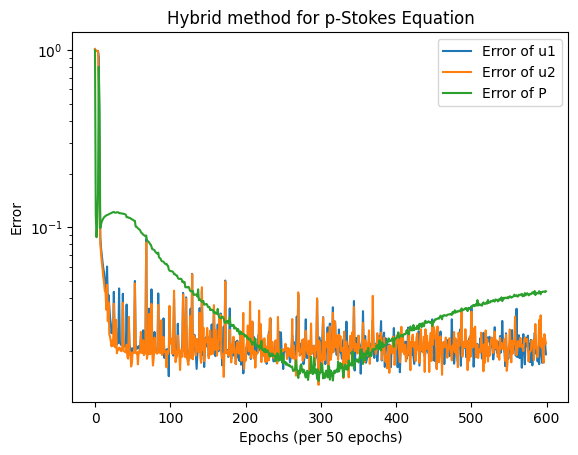

In [ ]:
import matplotlib.pyplot as plt

plt.plot(error_list1, label='Error of u1')
plt.plot(error_list2, label='Error of u2')
plt.plot(error_list3, label='Error of P')

plt.title('Hybrid method for p-Stokes Equation')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')
plt.yscale('log')

plt.legend()

plt.show()

Loss Curve

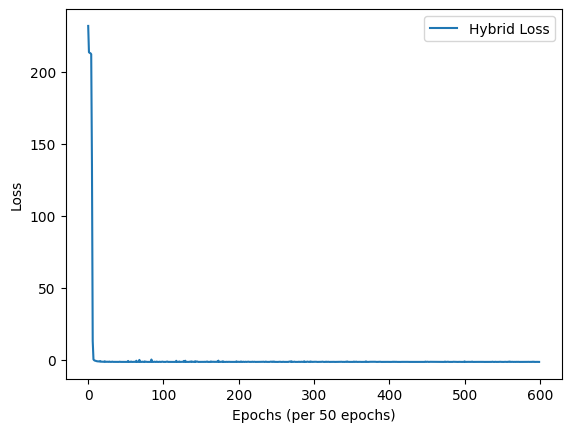

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_list1, label='Hybrid Loss')

#plt.title('Hybrid method for p-Stokes Equation')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Loss')
#plt.yscale('log')

plt.legend()

plt.show()

#Plotting Prediction

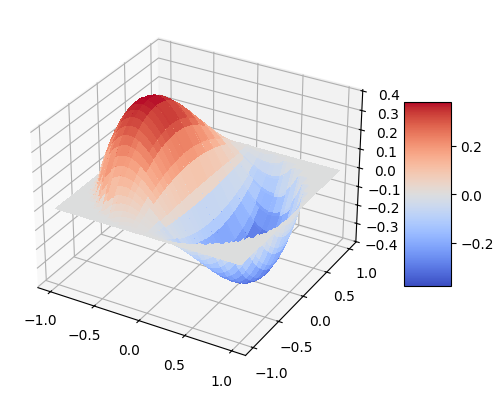

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

#Radius of circle domain
r=1

#Generate uniform points to visualize output functions
x_collocation = []
y_collocation = []
p_collocation = []

theta = np.linspace(0, 2*np.pi, 120)
x = np.cos(theta)
y = np.sin(theta)

X, Y = np.meshgrid(x, y)

pt_x = Variable(torch.from_numpy(X).float(), requires_grad=False).to(device)
pt_y = Variable(torch.from_numpy(Y).float(), requires_grad=False).to(device)

pt_x = pt_x.reshape(-1,1)
pt_y = pt_y.reshape(-1,1)
pt_p = 2*torch.ones_like(pt_x) + 2   #2 < p < 4

#Predicted functions
Predict1 = net_2d_1(pt_x, pt_y, pt_p)
Predict2 = net_2d_2(pt_x, pt_y, pt_p)
Predict3 = net_2d_P(pt_x, pt_y, pt_p)

#True solution functions
Truesol1 = k*pt_y * (r**2 - pt_x**2 - pt_y**2)
Truesol2 = -k*pt_x * (r**2 - pt_x**2 - pt_y**2)
Truesol3 = 3*(pt_x + pt_y)

Predict1 = Predict1.data.cpu().numpy()
Predict2 = Predict2.data.cpu().numpy()
Predict3 = Predict3.data.cpu().numpy()
Truesol1 = Truesol1.data.cpu().numpy()
Truesol2 = Truesol2.data.cpu().numpy()
Truesol3 = Truesol3.data.cpu().numpy()

PR_u1 = Predict1.reshape(X.shape)
PR_u2 = Predict2.reshape(X.shape)
PR_P = Predict3.reshape(X.shape)
Truesol1 = Truesol1.reshape(X.shape)
Truesol2 = Truesol2.reshape(X.shape)
Truesol3 = Truesol3.reshape(X.shape)

#Masking outside of domain
mask = (X**2 + Y**2 > r**2)
PR_u1[mask] = 0
PR_u2[mask] = 0
PR_P[mask] = 0
Truesol1[mask] = 0
Truesol2[mask] = 0
Truesol3[mask] = 0

#3D surface plot(Predicted function, Solution function, Difference)
surf = ax.plot_surface(X, Y, PR_u2, cmap=cm.coolwarm, linewidth=0, antialiased=False)
#surf = ax.plot_surface(X, Y, Truesol3, cmap=cm.coolwarm, linewidth=0, antialiased=False)
#surf = ax.plot_surface(X, Y, (Truesol3 - PR_P), cmap=cm.coolwarm, linewidth=0, antialiased=False)

#Display scale of graph
fig.colorbar(surf, shrink=0.5, aspect=4)
#plt.title('Solution - Prediction for p=3 (P)')

#Adjust z-axis
#ax.set_zlim(0, 1)  # z축의 값 범위를 설정
#ax.set_zticks(np.arange(0, 1, 0.1))  # z축 눈금을 0부터 1까지 0.1 간격으로 설정

plt.show()

# PINN for p-Stokes Equation

In [ ]:
M = 100

T = True
F = False

class Net_2D(nn.Module):
    def __init__(self):
        super(Net_2D, self).__init__()
        torch.manual_seed(1234) # Fix Initial_Parameter
        self.hidden_layer1 = nn.Linear(3,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer2 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer3 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer4 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer5 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.output_layer = nn.Linear(M,1, bias = T)

    def forward(self, x,y,p):
        inputs = torch.cat([x,y,p],axis=1)
        layer1_out = activation(self.hidden_layer1(inputs))
        layer2_out = activation(self.hidden_layer2(layer1_out))
        layer3_out = activation(self.hidden_layer3(layer2_out))
        layer4_out = activation(self.hidden_layer4(layer3_out))
        #layer5_out = activation(self.hidden_layer5(layer4_out))
        output = self.output_layer(layer4_out)

        return output

class Net_2D_f(nn.Module):
    def __init__(self):
        super(Net_2D_f, self).__init__()
        torch.manual_seed(1234) # Fix Initial_Parameter
        self.hidden_layer1 = nn.Linear(3,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer2 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer3 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer4 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer5 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.output_layer = nn.Linear(M,1, bias = T)

    def forward(self, x,y,p):
        inputs = torch.cat([x,y,p],axis=1)
        layer1_out = activation_(self.hidden_layer1(inputs))
        layer2_out = activation_(self.hidden_layer2(layer1_out))
        layer3_out = activation_(self.hidden_layer3(layer2_out))
        layer4_out = activation_(self.hidden_layer4(layer3_out))
        #layer5_out = activation(self.hidden_layer5(layer4_out))
        output = self.output_layer(layer4_out)

        return output

In [ ]:
mse_cost_function = torch.nn.MSELoss()

net_pinn_1 = Net_2D()
net_pinn_1 = net_pinn_1.to(device)

net_pinn_2 = Net_2D()
net_pinn_2 = net_pinn_2.to(device)

net_pinn_P = Net_2D_f()
net_pinn_P = net_pinn_P.to(device)

optimizer1_p = torch.optim.Adam(net_pinn_1.parameters(),lr=0.001)
optimizer2_p = torch.optim.Adam(net_pinn_2.parameters(),lr=0.001)
optimizerP_p = torch.optim.Adam(net_pinn_P.parameters(),lr=0.001)

In [ ]:
def f3(x,y,p,x_bdy,y_bdy, f1,f2, net1, net2, netP):

    ##------------------------ Network output -------------------------------

    P = netP(x,y,p)
    w = net1(x,y,p)
    v = net2(x,y,p)

    w_bdy = net1(x_bdy,y_bdy,p)
    v_bdy = net2(x_bdy,y_bdy,p)

    ##--------------------Differentiation--------------------------

    P_x = torch.autograd.grad(P.sum(), x, create_graph=True)[0]
    P_y = torch.autograd.grad(P.sum(), y, create_graph=True)[0]

    w_x = torch.autograd.grad(w.sum(), x, create_graph=True)[0]
    w_y = torch.autograd.grad(w.sum(), y, create_graph=True)[0]

    v_x = torch.autograd.grad(v.sum(), x, create_graph=True)[0]
    v_y = torch.autograd.grad(v.sum(), y, create_graph=True)[0]

    AbsDu = (w_x**2 + w_y**2 + v_x**2 + v_y**2)**((p-2)/2)

    div11 = torch.autograd.grad((AbsDu*w_x).sum(), x, create_graph=True)[0]
    div12 = torch.autograd.grad((AbsDu*w_y).sum(), y, create_graph=True)[0]
    div21 = torch.autograd.grad((AbsDu*v_x).sum(), x, create_graph=True)[0]
    div22 = torch.autograd.grad((AbsDu*v_y).sum(), y, create_graph=True)[0]

    ##-----------------------Calculate Variational----------------------------

    Integral = (P.mean())**2

    Bdy = (w_bdy**2 + v_bdy**2).mean()

    Div = ((w_x + v_y)**2).mean()

    gradP = ((P_x - f1 - div11 - div12)**2).mean() + ((P_y - f2 - div21 - div22)**2).mean()

    ##----------------------------Loss function-------------------------------

    return gradP + Integral + 1000*Bdy + 1000*Div

In [ ]:
# Function to check if a point is inside the circle
def is_inside(x, y):

    return x**2 + y**2 < 1


# Generate random points inside the domain
def generate_random_points(n_points=1000):
    points = []
    while len(points) < n_points:
        x = np.random.uniform(-1, 1)
        y = np.random.uniform(-1, 1)
        if is_inside(x, y):
            points.append((x, y))
    return np.array(points)

# Example usage
random_points = generate_random_points(2000)

x_coords_ = random_points[:, 0].reshape(-1, 1)
y_coords_ = random_points[:, 1].reshape(-1, 1)
p_coords_ = (2*np.random.rand(len(x_coords_)) + 2).reshape(-1, 1)   #2 < p < 4

pt_x_collocation = Variable(torch.from_numpy(x_coords_).float(), requires_grad=True).to(device)
pt_y_collocation = Variable(torch.from_numpy(y_coords_).float(), requires_grad=True).to(device)
pt_p_collocation = Variable(torch.from_numpy(p_coords_).float(), requires_grad=True).to(device)

##-----------------------------set F-------------------------------------------------

pt_x = Variable(torch.from_numpy(x_coords_).float(), requires_grad=False).to(device)
pt_y = Variable(torch.from_numpy(y_coords_).float(), requires_grad=False).to(device)
pt_p = Variable(torch.from_numpy(p_coords_).float(), requires_grad=False).to(device)

pt_Q = k**(pt_p - 2)*(8*(pt_x**2)*(pt_y**2) + (1 - pt_x**2 - 3*(pt_y**2))**2 + (-1 + 3*(pt_x**2) + pt_y**2)**2)**((pt_p-2)/2)
pt_Q_x = k**(pt_p - 2)*((pt_p-2)/2*(8*(pt_x**2)*(pt_y**2) + (1 - pt_x**2 - 3*(pt_y**2))**2 + (-1 + 3*(pt_x**2) + pt_y**2)**2)**((pt_p-4)/2) * (16*(pt_x)*(pt_y**2) - 4*pt_x*(1 - pt_x**2 - 3*(pt_y**2)) + 12*pt_x*(-1 + 3*(pt_x**2) + pt_y**2)))
pt_Q_y = k**(pt_p - 2)*((pt_p-2)/2*(8*(pt_x**2)*(pt_y**2) + (1 - pt_x**2 - 3*(pt_y**2))**2 + (-1 + 3*(pt_x**2) + pt_y**2)**2)**((pt_p-4)/2) * (16*(pt_x**2)*(pt_y) - 12*pt_y*(1 - pt_x**2 - 3*(pt_y**2)) + 4*pt_y*(-1 + 3*(pt_x**2) + pt_y**2)))

F1 = -(pt_Q_x*(-2*pt_x*pt_y) + pt_Q*(-2*pt_y) + pt_Q_y*(1 - pt_x**2 - 3*pt_y**2) + pt_Q*(-6*pt_y)) + 3
F2 = -(pt_Q_x*(-1 + 3*pt_x**2 + pt_y**2) + pt_Q*(6*pt_x) + pt_Q_y*(2*pt_x*pt_y) + pt_Q*(2*pt_x)) + 3

In [ ]:
#Boundary
theta1 = np.linspace(0, 2*np.pi, 2000)

x_coords1 = np.cos(theta1).reshape(-1, 1)
y_coords1 = np.sin(theta1).reshape(-1, 1)

bdy_x = Variable(torch.from_numpy(x_coords1).float(), requires_grad=True).to(device)
bdy_y = Variable(torch.from_numpy(y_coords1).float(), requires_grad=True).to(device)

In [ ]:
#u1 solution
sol_u = k*(pt_y*(1 - pt_x**2 - pt_y**2))

#u2 solution
sol_v = k*(-pt_x*(1 - pt_x**2 - pt_y**2))

#P solution
sol_P = 3*(pt_x + pt_y)

In [ ]:
error_pinn_list1 = []
error_pinn_list2 = []
error_pinn_list3 = []
loss_list2 = []

previous_validation_loss = 99999999.0
epoch = 0

while epoch < 30000:
    optimizer1_p.zero_grad()
    optimizer2_p.zero_grad()
    optimizerP_p.zero_grad()

##------------------------------------Compute Loss-----------------------------------------##

    loss = 1*f3(pt_x_collocation, pt_y_collocation, pt_p_collocation, bdy_x, bdy_y, F1,F2, net_pinn_1,net_pinn_2,net_pinn_P)

##------------------------------------Optimize Loss-----------------------------------------##

    loss.backward()
    optimizer1_p.step()
    optimizer2_p.step()
    optimizerP_p.step()

    epoch += 1

##----------------------------Adaptive learningrate-----------------------------##

    if (epoch) % 50 == 1:
        print("-----------------------------------------------------------------------------")
        print("Epoch:",epoch)

        gap1 = torch.sqrt((((sol_u - net_pinn_1(pt_x, pt_y, pt_p))**2).mean())/((sol_u)**2).mean())
        gap2 = torch.sqrt((((sol_v - net_pinn_2(pt_x, pt_y, pt_p))**2).mean())/((sol_v)**2).mean())
        gap3 = torch.sqrt((((sol_P - net_pinn_P(pt_x, pt_y, pt_p))**2).mean())/((sol_P)**2).mean())

        print('error of u1:',gap1)
        print('error of u2:',gap2)
        print('error of P:',gap3)

        print("Loss :", (loss).item())
        error_pinn_list1.append(gap1.item())
        error_pinn_list2.append(gap2.item())
        error_pinn_list3.append(gap3.item())
        loss_list2.append(loss.item())

-----------------------------------------------------------------------------
Epoch: 1
error of u1: tensor(1.0144, device='cuda:0', grad_fn=<SqrtBackward0>)
error of u2: tensor(1.0222, device='cuda:0', grad_fn=<SqrtBackward0>)
error of P: tensor(0.9971, device='cuda:0', grad_fn=<SqrtBackward0>)
Loss : 244.7177276611328
-----------------------------------------------------------------------------
Epoch: 51
error of u1: tensor(1.0004, device='cuda:0', grad_fn=<SqrtBackward0>)
error of u2: tensor(1.0003, device='cuda:0', grad_fn=<SqrtBackward0>)
error of P: tensor(0.1215, device='cuda:0', grad_fn=<SqrtBackward0>)
Loss : 226.14280700683594
-----------------------------------------------------------------------------
Epoch: 101
error of u1: tensor(1.0000, device='cuda:0', grad_fn=<SqrtBackward0>)
error of u2: tensor(1.0002, device='cuda:0', grad_fn=<SqrtBackward0>)
error of P: tensor(0.1522, device='cuda:0', grad_fn=<SqrtBackward0>)
Loss : 225.6471710205078
---------------------------------

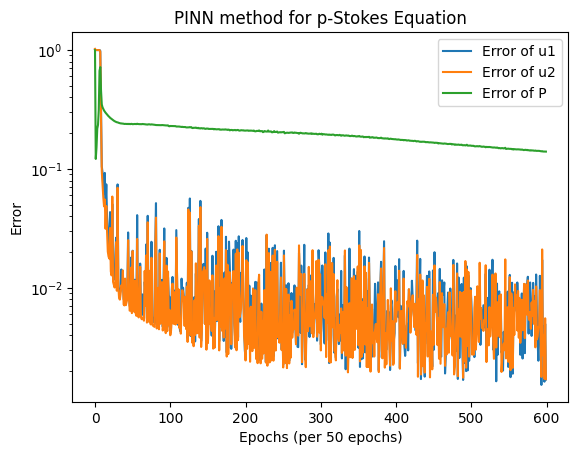

In [ ]:
import matplotlib.pyplot as plt

plt.plot(error_pinn_list1, label='Error of u1')
plt.plot(error_pinn_list2, label='Error of u2')
plt.plot(error_pinn_list3, label='Error of P')

plt.title('PINN method for p-Stokes Equation')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')
plt.yscale('log')

plt.legend()

plt.show()

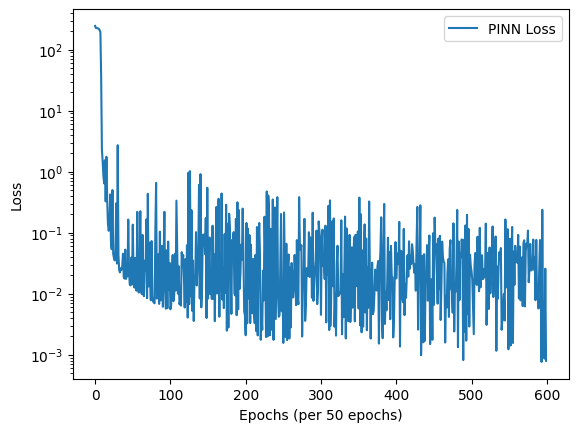

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_list2, label='PINN Loss')

#plt.title('DRM for p-Stokes Equation')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Loss')
plt.yscale('log')

plt.legend()

plt.show()

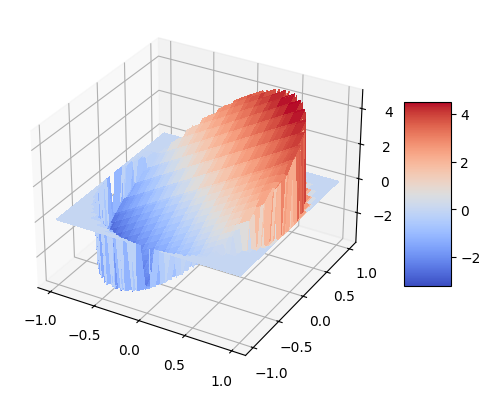

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

#Radius of circle domain
r=1

#Generate uniform points to visualize output functions
x_collocation = []
y_collocation = []
p_collocation = []

theta = np.linspace(0, 2*np.pi, 120)
x = np.cos(theta)
y = np.sin(theta)

X, Y = np.meshgrid(x, y)

pt_x = Variable(torch.from_numpy(X).float(), requires_grad=False).to(device)
pt_y = Variable(torch.from_numpy(Y).float(), requires_grad=False).to(device)

pt_x = pt_x.reshape(-1,1)
pt_y = pt_y.reshape(-1,1)
pt_p = 2*torch.ones_like(pt_x) + 2   #2 < p < 4

#Predicted functions
Predict1 = net_pinn_1(pt_x, pt_y, pt_p)
Predict2 = net_pinn_2(pt_x, pt_y, pt_p)
Predict3 = net_pinn_P(pt_x, pt_y, pt_p)

#True solution functions
Truesol1 = k*pt_y * (r**2 - pt_x**2 - pt_y**2)
Truesol2 = -k*pt_x * (r**2 - pt_x**2 - pt_y**2)
Truesol3 = 3*(pt_x + pt_y)

Predict1 = Predict1.data.cpu().numpy()
Predict2 = Predict2.data.cpu().numpy()
Predict3 = Predict3.data.cpu().numpy()
Truesol1 = Truesol1.data.cpu().numpy()
Truesol2 = Truesol2.data.cpu().numpy()
Truesol3 = Truesol3.data.cpu().numpy()

PR_u1 = Predict1.reshape(X.shape)
PR_u2 = Predict2.reshape(X.shape)
PR_P = Predict3.reshape(X.shape)
Truesol1 = Truesol1.reshape(X.shape)
Truesol2 = Truesol2.reshape(X.shape)
Truesol3 = Truesol3.reshape(X.shape)

#Masking outside of domain
mask = (X**2 + Y**2 > r**2)
PR_u1[mask] = 0
PR_u2[mask] = 0
PR_P[mask] = 0
Truesol1[mask] = 0
Truesol2[mask] = 0
Truesol3[mask] = 0

#3D surface plot(Predicted function, Solution function, Difference)
surf = ax.plot_surface(X, Y, PR_P, cmap=cm.coolwarm, linewidth=0, antialiased=False)
#surf = ax.plot_surface(X, Y, Truesol3, cmap=cm.coolwarm, linewidth=0, antialiased=False)
#surf = ax.plot_surface(X, Y, (Truesol3 - PR_P), cmap=cm.coolwarm, linewidth=0, antialiased=False)

#Display scale of graph
fig.colorbar(surf, shrink=0.5, aspect=4)
#plt.title('Solution - Prediction for p=3 (P)')

#Adjust z-axis
#ax.set_zlim(0, 1)  # z축의 값 범위를 설정
#ax.set_zticks(np.arange(0, 1, 0.1))  # z축 눈금을 0부터 1까지 0.1 간격으로 설정

plt.show()

# DRM for p-Stokes Equation

In [ ]:
M = 100

T = True
F = False

class Net_2D(nn.Module):
    def __init__(self):
        super(Net_2D, self).__init__()
        torch.manual_seed(1234) # Fix Initial_Parameter
        self.hidden_layer1 = nn.Linear(3,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer2 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer3 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer4 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        #self.hidden_layer5 = nn.Linear(M,M, bias = T)
        #torch.manual_seed(1234)
        self.output_layer = nn.Linear(M,1, bias = T)

    def forward(self, x,y,p):
        inputs = torch.cat([x,y,p],axis=1)
        layer1_out = activation(self.hidden_layer1(inputs))
        layer2_out = activation(self.hidden_layer2(layer1_out))
        layer3_out = activation(self.hidden_layer3(layer2_out))
        layer4_out = activation(self.hidden_layer4(layer3_out))
        #layer5_out = activation(self.hidden_layer5(layer4_out))
        output = self.output_layer(layer4_out)

        return output

class Net_2D_f(nn.Module):
    def __init__(self):
        super(Net_2D_f, self).__init__()
        torch.manual_seed(1234) # Fix Initial_Parameter
        self.hidden_layer1 = nn.Linear(3,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer2 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer3 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        self.hidden_layer4 = nn.Linear(M,M, bias = T)
        torch.manual_seed(1234)
        #self.hidden_layer5 = nn.Linear(M,M, bias = T)
        #torch.manual_seed(1234)
        self.output_layer = nn.Linear(M,1, bias = T)

    def forward(self, x,y,p):
        inputs = torch.cat([x,y,p],axis=1)
        layer1_out = activation_(self.hidden_layer1(inputs))
        layer2_out = activation_(self.hidden_layer2(layer1_out))
        layer3_out = activation_(self.hidden_layer3(layer2_out))
        layer4_out = activation_(self.hidden_layer4(layer3_out))
        #layer5_out = activation(self.hidden_layer5(layer4_out))
        output = self.output_layer(layer4_out)

        return output

In [ ]:
mse_cost_function = torch.nn.MSELoss() #MSE Function can be shared

net_drm_1 = Net_2D()
net_drm_1 = net_drm_1.to(device)

net_drm_2 = Net_2D()
net_drm_2 = net_drm_2.to(device)

net_drm_P = Net_2D_f()
net_drm_P = net_drm_P.to(device)

optimizer1_d = torch.optim.Adam(net_drm_1.parameters(),lr=0.001)
optimizer2_d = torch.optim.Adam(net_drm_2.parameters(),lr=0.001)
optimizerP_d = torch.optim.Adam(net_drm_P.parameters(),lr=0.001)

In [ ]:
def f3(x,y,p,x_bdy,y_bdy, f1,f2, net1, net2, netP):

    ##------------------------ Network output -------------------------------

    P = netP(x,y,p)
    w = net1(x,y,p)
    v = net2(x,y,p)

    w_bdy = net1(x_bdy,y_bdy,p)
    v_bdy = net2(x_bdy,y_bdy,p)

    ##--------------------Differentiation--------------------------

    P_x = torch.autograd.grad(P.sum(), x, create_graph=True)[0]
    P_y = torch.autograd.grad(P.sum(), y, create_graph=True)[0]

    w_x = torch.autograd.grad(w.sum(), x, create_graph=True)[0]
    w_y = torch.autograd.grad(w.sum(), y, create_graph=True)[0]

    v_x = torch.autograd.grad(v.sum(), x, create_graph=True)[0]
    v_y = torch.autograd.grad(v.sum(), y, create_graph=True)[0]

    AbsDu = (w_x**2 + w_y**2 + v_x**2 + v_y**2)**((p-2)/2)

    div11 = torch.autograd.grad((AbsDu*w_x).sum(), x, create_graph=True)[0]
    div12 = torch.autograd.grad((AbsDu*w_y).sum(), y, create_graph=True)[0]
    div21 = torch.autograd.grad((AbsDu*v_x).sum(), x, create_graph=True)[0]
    div22 = torch.autograd.grad((AbsDu*v_y).sum(), y, create_graph=True)[0]

    ##-----------------------Calculate Variational----------------------------

    Integral = (P.mean())**2

    Bdy = (w_bdy**2 + v_bdy**2).mean()

    Var = ((1/p)*(w_x**2 + w_y**2 + v_x**2 + v_y**2)**(p/2) - (f1*w + f2*v)).mean()

    Div = ((w_x + v_y)**2).mean()

    ##----------------------------Loss function-------------------------------

    return Var + Integral + 1000*Bdy + 1000*Div

In [ ]:
# Function to check if a point is inside the circle
def is_inside(x, y):

    return x**2 + y**2 < 1


# Generate random points inside the domain
def generate_random_points(n_points=1000):
    points = []
    while len(points) < n_points:
        x = np.random.uniform(-1, 1)
        y = np.random.uniform(-1, 1)
        if is_inside(x, y):
            points.append((x, y))
    return np.array(points)

# Example usage
random_points = generate_random_points(2000)

x_coords_ = random_points[:, 0].reshape(-1, 1)
y_coords_ = random_points[:, 1].reshape(-1, 1)
p_coords_ = (2*np.random.rand(len(x_coords_)) + 2).reshape(-1, 1)   #2 < p < 4

pt_x_collocation = Variable(torch.from_numpy(x_coords_).float(), requires_grad=True).to(device)
pt_y_collocation = Variable(torch.from_numpy(y_coords_).float(), requires_grad=True).to(device)
pt_p_collocation = Variable(torch.from_numpy(p_coords_).float(), requires_grad=True).to(device)

#-----------------------------set F-------------------------------------------------

pt_x = Variable(torch.from_numpy(x_coords_).float(), requires_grad=False).to(device)
pt_y = Variable(torch.from_numpy(y_coords_).float(), requires_grad=False).to(device)
pt_p = Variable(torch.from_numpy(p_coords_).float(), requires_grad=False).to(device)

pt_Q = k**(pt_p - 2)*(8*(pt_x**2)*(pt_y**2) + (1 - pt_x**2 - 3*(pt_y**2))**2 + (-1 + 3*(pt_x**2) + pt_y**2)**2)**((pt_p-2)/2)
pt_Q_x = k**(pt_p - 2)*((pt_p-2)/2*(8*(pt_x**2)*(pt_y**2) + (1 - pt_x**2 - 3*(pt_y**2))**2 + (-1 + 3*(pt_x**2) + pt_y**2)**2)**((pt_p-4)/2) * (16*(pt_x)*(pt_y**2) - 4*pt_x*(1 - pt_x**2 - 3*(pt_y**2)) + 12*pt_x*(-1 + 3*(pt_x**2) + pt_y**2)))
pt_Q_y = k**(pt_p - 2)*((pt_p-2)/2*(8*(pt_x**2)*(pt_y**2) + (1 - pt_x**2 - 3*(pt_y**2))**2 + (-1 + 3*(pt_x**2) + pt_y**2)**2)**((pt_p-4)/2) * (16*(pt_x**2)*(pt_y) - 12*pt_y*(1 - pt_x**2 - 3*(pt_y**2)) + 4*pt_y*(-1 + 3*(pt_x**2) + pt_y**2)))

F1 = -(pt_Q_x*(-2*pt_x*pt_y) + pt_Q*(-2*pt_y) + pt_Q_y*(1 - pt_x**2 - 3*pt_y**2) + pt_Q*(-6*pt_y)) + 3
F2 = -(pt_Q_x*(-1 + 3*pt_x**2 + pt_y**2) + pt_Q*(6*pt_x) + pt_Q_y*(2*pt_x*pt_y) + pt_Q*(2*pt_x)) + 3

In [ ]:
#Boundary

theta1 = np.linspace(0, 2*np.pi, 2000)

x_coords1 = np.cos(theta1).reshape(-1, 1)
y_coords1 = np.sin(theta1).reshape(-1, 1)

bdy_x = Variable(torch.from_numpy(x_coords1).float(), requires_grad=True).to(device)
bdy_y = Variable(torch.from_numpy(y_coords1).float(), requires_grad=True).to(device)

In [ ]:
#u1 solution
sol_u = k*(pt_y*(1 - pt_x**2 - pt_y**2))

#u2 solution
sol_v = k*(-pt_x*(1 - pt_x**2 - pt_y**2))

#P solution
sol_P = 3*(pt_x + pt_y)

In [ ]:
error_drm_list1 = []
error_drm_list2 = []
error_drm_list3 = []
loss_list3 = []

previous_validation_loss = 99999999.0
epoch = 0

while epoch < 30000:
    optimizer1_d.zero_grad()
    optimizer2_d.zero_grad()
    optimizerP_d.zero_grad()

##------------------------------------Compute Loss-----------------------------------------##

    loss = 1*f3(pt_x_collocation, pt_y_collocation, pt_p_collocation, bdy_x, bdy_y, F1,F2, net_drm_1,net_drm_2,net_drm_P)

##------------------------------------Optimize Loss-----------------------------------------##

    loss.backward()
    optimizer1_d.step()
    optimizer2_d.step()
    optimizerP_d.step()

    epoch += 1

##----------------------------Adaptive learningrate-----------------------------##

    if (epoch) % 50 == 1:
        print("-----------------------------------------------------------------------------")
        print("Epoch:",epoch)

        gap11 = torch.sqrt((((sol_u - net_drm_1(pt_x, pt_y, pt_p))**2).mean())/((sol_u)**2).mean())
        gap22 = torch.sqrt((((sol_v - net_drm_2(pt_x, pt_y, pt_p))**2).mean())/((sol_v)**2).mean())
        gap33 = torch.sqrt((((sol_P - net_drm_P(pt_x, pt_y, pt_p))**2).mean())/((sol_P)**2).mean())

        print('error of u1:',gap11)
        print('error of u2:',gap22)
        print('error of P:',gap33)

        print("Loss :", (loss).item())
        error_drm_list1.append(gap11.item())
        error_drm_list2.append(gap22.item())
        error_drm_list3.append(gap33.item())
        loss_list3.append(loss.item())

-----------------------------------------------------------------------------
Epoch: 1
error of u1: tensor(1.0070, device='cuda:0', grad_fn=<SqrtBackward0>)
error of u2: tensor(1.0191, device='cuda:0', grad_fn=<SqrtBackward0>)
error of P: tensor(0.9992, device='cuda:0', grad_fn=<SqrtBackward0>)
Loss : 0.12665747106075287
-----------------------------------------------------------------------------
Epoch: 51
error of u1: tensor(0.9920, device='cuda:0', grad_fn=<SqrtBackward0>)
error of u2: tensor(0.9922, device='cuda:0', grad_fn=<SqrtBackward0>)
error of P: tensor(0.9998, device='cuda:0', grad_fn=<SqrtBackward0>)
Loss : -0.01968725025653839
-----------------------------------------------------------------------------
Epoch: 101
error of u1: tensor(0.9916, device='cuda:0', grad_fn=<SqrtBackward0>)
error of u2: tensor(0.9920, device='cuda:0', grad_fn=<SqrtBackward0>)
error of P: tensor(0.9998, device='cuda:0', grad_fn=<SqrtBackward0>)
Loss : -0.02314257249236107
--------------------------

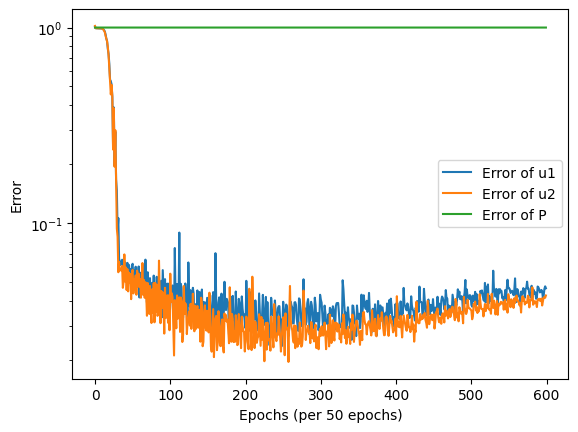

In [ ]:
import matplotlib.pyplot as plt

plt.plot(error_drm_list1, label='Error of u1')
plt.plot(error_drm_list2, label='Error of u2')
plt.plot(error_drm_list3, label='Error of P')

#plt.title('DRM for p-Stokes Equation')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')
plt.yscale('log')

plt.legend()

plt.show()

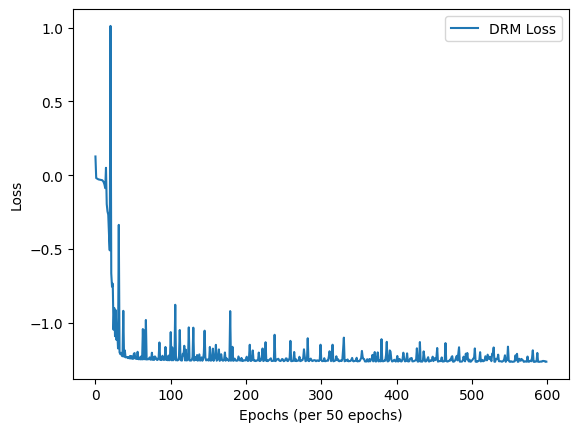

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_list3, label='DRM Loss')

#plt.title('DRM for p-Stokes Equation')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Loss')
#plt.yscale('log')

plt.legend()

plt.show()

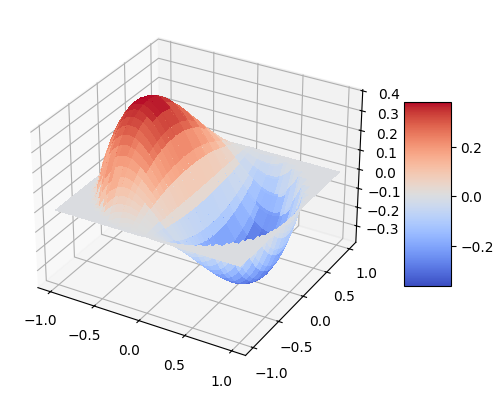

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

#Radius of circle domain
r=1

#Generate uniform points to visualize output functions
x_collocation = []
y_collocation = []
p_collocation = []

theta = np.linspace(0, 2*np.pi, 120)
x = np.cos(theta)
y = np.sin(theta)

X, Y = np.meshgrid(x, y)

pt_x = Variable(torch.from_numpy(X).float(), requires_grad=False).to(device)
pt_y = Variable(torch.from_numpy(Y).float(), requires_grad=False).to(device)

pt_x = pt_x.reshape(-1,1)
pt_y = pt_y.reshape(-1,1)
pt_p = 2.5*torch.ones_like(pt_x)   #2 < p < 4

#Predicted functions
Predict1 = net_drm_1(pt_x, pt_y, pt_p)
Predict2 = net_drm_2(pt_x, pt_y, pt_p)
Predict3 = net_drm_P(pt_x, pt_y, pt_p)

#True solution functions
Truesol1 = k*pt_y * (r**2 - pt_x**2 - pt_y**2)
Truesol2 = -k*pt_x * (r**2 - pt_x**2 - pt_y**2)
Truesol3 = 3*(pt_x + pt_y)

Predict1 = Predict1.data.cpu().numpy()
Predict2 = Predict2.data.cpu().numpy()
Predict3 = Predict3.data.cpu().numpy()
Truesol1 = Truesol1.data.cpu().numpy()
Truesol2 = Truesol2.data.cpu().numpy()
Truesol3 = Truesol3.data.cpu().numpy()

PR_u1 = Predict1.reshape(X.shape)
PR_u2 = Predict2.reshape(X.shape)
PR_P = Predict3.reshape(X.shape)
Truesol1 = Truesol1.reshape(X.shape)
Truesol2 = Truesol2.reshape(X.shape)
Truesol3 = Truesol3.reshape(X.shape)

#Masking outside of domain
mask = (X**2 + Y**2 > r**2)
PR_u1[mask] = 0
PR_u2[mask] = 0
PR_P[mask] = 0
Truesol1[mask] = 0
Truesol2[mask] = 0
Truesol3[mask] = 0

#3D surface plot(Predicted function, Solution function, Difference)
surf = ax.plot_surface(X, Y, PR_u2, cmap=cm.coolwarm, linewidth=0, antialiased=False)
#surf = ax.plot_surface(X, Y, Truesol3, cmap=cm.coolwarm, linewidth=0, antialiased=False)
#surf = ax.plot_surface(X, Y, (Truesol3 - PR_P), cmap=cm.coolwarm, linewidth=0, antialiased=False)

#Display scale of graph
fig.colorbar(surf, shrink=0.5, aspect=4)
#plt.title('Solution - Prediction for p=3 (P)')

#Adjust z-axis
#ax.set_zlim(0, 1)  # z축의 값 범위를 설정
#ax.set_zticks(np.arange(0, 1, 0.1))  # z축 눈금을 0부터 1까지 0.1 간격으로 설정

plt.show()

# Plots

**Comparing u1 with x=0 or y=0**

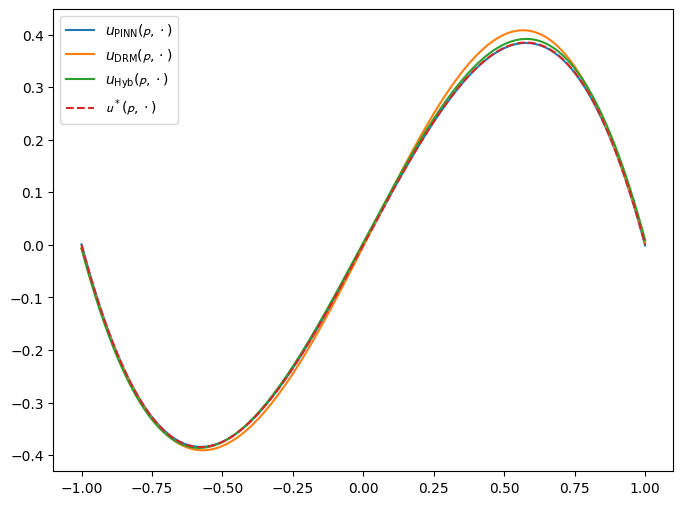

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

# Set a fixed p value
p = 3.5

y_np = np.linspace(-1, 1, 500)
p_np = p*np.ones_like(y_np)
#x_np = np.zeros_like(y_np)
x_np = np.zeros_like(y_np)

x = Variable(torch.from_numpy(x_np).float().unsqueeze(1), requires_grad=True).to(device)
y = Variable(torch.from_numpy(y_np).float().unsqueeze(1), requires_grad=True).to(device)
p = Variable(torch.from_numpy(p_np).float().unsqueeze(1), requires_grad=True).to(device)

# Functions
z_PINN = net_pinn_1(x, y, p).cpu().detach().numpy()
z_PINN_df = (k*y*(1 - x**2 - y**2) - net_pinn_1(x, y, p)).cpu().detach().numpy()
z_DRM = net_drm_1(x, y, p).cpu().detach().numpy()
z_DRM_df = (k*y*(1 - x**2 - y**2) - net_drm_1(x, y, p)).cpu().detach().numpy()
z_Mix = net_2d_1(x, y, p).cpu().detach().numpy()
z_Mix_df = (k*y*(1 - x**2 - y**2) - net_2d_1(x, y, p)).cpu().detach().numpy()
z_Sol = (k*y*(1 - x**2 - y**2)).cpu().detach().numpy()

# Predicted functions and solution function
plt.figure(figsize=(8, 6))
#plt.rcParams["text.usetex"] = False
plt.plot(y_np, z_PINN, label=r"$u_\mathrm{PINN}(\mathcal{p}, \cdot)$")
plt.plot(y_np, z_DRM, label=r"$u_\mathrm{DRM}(\mathcal{p}, \cdot)$")
plt.plot(y_np, z_Mix, label=r"$u_\mathrm{Hyb}(\mathcal{p}, \cdot)$")
plt.plot(y_np, z_Sol, linestyle = '--', label=r"$\mathcal{u}^*(\mathcal{p}, \cdot)$")

#Difference functions
#plt.plot(y_np, z_PINN_df, label=r"$u^{*}(\mathcal{p}, \cdot) - u_\mathrm{PINN}(\mathcal{p}, \cdot)$")
#plt.plot(y_np, z_DRM_df, label=r"$u^{*}(\mathcal{p}, \cdot) - u_\mathrm{DRM}(\mathcal{p}, \cdot)$")
#plt.plot(y_np, z_Mix_df, label=r"$u^{*}(\mathcal{p}, \cdot) - u_\mathrm{Hyb}(\mathcal{p}, \cdot)$")

#plt.title("w = 6")
#plt.xlabel("y")
#plt.ylabel("f(x, y)")
#plt.ylim(0,0.12)
plt.legend()
#plt.grid()
plt.show()

**Comparing u2 with x=0 or y=0**

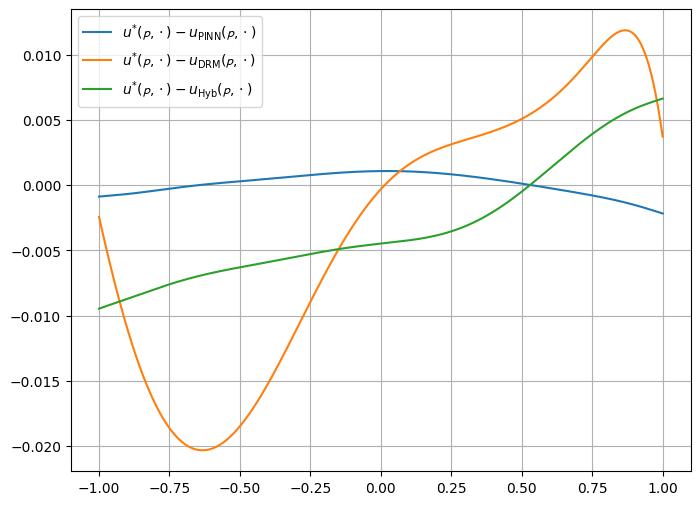

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

# Set a fixed p value
p = 3.5

x_np = np.linspace(-1, 1, 500)
p_np = p*np.ones_like(x_np)
#x_np = np.zeros_like(y_np)
y_np = np.zeros_like(x_np)

x = Variable(torch.from_numpy(x_np).float().unsqueeze(1), requires_grad=True).to(device)
y = Variable(torch.from_numpy(y_np).float().unsqueeze(1), requires_grad=True).to(device)
p = Variable(torch.from_numpy(p_np).float().unsqueeze(1), requires_grad=True).to(device)

# Functions
z_PINN = net_pinn_2(x, y, p).cpu().detach().numpy()
z_PINN_df = (-k*x*(1 - x**2 - y**2) - net_pinn_2(x, y, p)).cpu().detach().numpy()
z_DRM = net_drm_2(x, y, p).cpu().detach().numpy()
z_DRM_df = (-k*x*(1 - x**2 - y**2) - net_drm_2(x, y, p)).cpu().detach().numpy()
z_Mix = net_2d_2(x, y, p).cpu().detach().numpy()
z_Mix_df = (-k*x*(1 - x**2 - y**2) - net_2d_2(x, y, p)).cpu().detach().numpy()
z_Sol = (-k*x*(1 - x**2 - y**2)).cpu().detach().numpy()

# Predicted functions and solution function
plt.figure(figsize=(8, 6))
#plt.rcParams["text.usetex"] = False
#plt.plot(x_np, z_PINN, label=r"$u_\mathrm{PINN}(\mathcal{p}, \cdot)$")
#plt.plot(x_np, z_DRM, label=r"$u_\mathrm{DRM}(\mathcal{p}, \cdot)$")
#plt.plot(x_np, z_Mix, label=r"$u_\mathrm{Hyb}(\mathcal{p}, \cdot)$")
#plt.plot(x_np, z_Sol, linestyle = '--', label=r"$\mathcal{u}^*(\mathcal{p}, \cdot)$")

# Difference functions
plt.plot(x_np, z_PINN_df, label=r"$u^{*}(\mathcal{p}, \cdot) - u_\mathrm{PINN}(\mathcal{p}, \cdot)$")
plt.plot(x_np, z_DRM_df, label=r"$u^{*}(\mathcal{p}, \cdot) - u_\mathrm{DRM}(\mathcal{p}, \cdot)$")
plt.plot(x_np, z_Mix_df, label=r"$u^{*}(\mathcal{p}, \cdot) - u_\mathrm{Hyb}(\mathcal{p}, \cdot)$")

#plt.title("w = 6")
#plt.xlabel("y")
#plt.ylabel("f(x, y)")
#plt.ylim(0,0.12)
plt.legend()
plt.grid()
plt.show()

**Comparing P with x=0 or y=0**

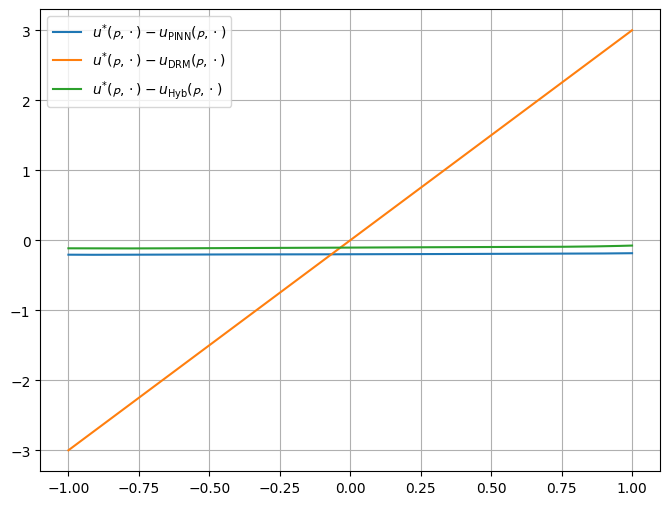

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import torch
from torch.autograd import Variable

# Set a fixed p value
p = 3.5

y_np = np.linspace(-1, 1, 500)
p_np = p*np.ones_like(y_np)
#x_np = np.zeros_like(y_np)
x_np = np.zeros_like(y_np)

x = Variable(torch.from_numpy(x_np).float().unsqueeze(1), requires_grad=True).to(device)
y = Variable(torch.from_numpy(y_np).float().unsqueeze(1), requires_grad=True).to(device)
p = Variable(torch.from_numpy(p_np).float().unsqueeze(1), requires_grad=True).to(device)

# Functions
z_PINN = net_pinn_P(x, y, p).cpu().detach().numpy()
z_PINN_df = (3*(x + y) - net_pinn_P(x, y, p)).cpu().detach().numpy()
z_DRM = net_drm_P(x, y, p).cpu().detach().numpy()
z_DRM_df = (3*(x + y) - net_drm_P(x, y, p)).cpu().detach().numpy()
z_Mix = net_2d_P(x, y, p).cpu().detach().numpy()
z_Mix_df = (3*(x + y) - net_2d_P(x, y, p)).cpu().detach().numpy()
z_Sol = (3*(x + y)).cpu().detach().numpy()

# Predicted functions and solution function
plt.figure(figsize=(8, 6))
#plt.rcParams["text.usetex"] = False
#plt.plot(y_np, z_PINN, label=r"$u_\mathrm{PINN}(\mathcal{p}, \cdot)$")
#plt.plot(y_np, z_DRM, label=r"$u_\mathrm{DRM}(\mathcal{p}, \cdot)$")
#plt.plot(y_np, z_Mix, label=r"$u_\mathrm{Hyb}(\mathcal{p}, \cdot)$")
#plt.plot(y_np, z_Sol, linestyle = '--', label=r"$\mathcal{u}^*(\mathcal{p}, \cdot)$")

# Difference functions
plt.plot(y_np, z_PINN_df, label=r"$u^{*}(\mathcal{p}, \cdot) - u_\mathrm{PINN}(\mathcal{p}, \cdot)$")
plt.plot(y_np, z_DRM_df, label=r"$u^{*}(\mathcal{p}, \cdot) - u_\mathrm{DRM}(\mathcal{p}, \cdot)$")
plt.plot(y_np, z_Mix_df, label=r"$u^{*}(\mathcal{p}, \cdot) - u_\mathrm{Hyb}(\mathcal{p}, \cdot)$")

#plt.title("w = 6")
#plt.xlabel("y")
#plt.ylabel("f(x, y)")
#plt.ylim(0,0.12)
plt.legend()
plt.grid()
plt.show()

**Parametric graphs with x=0 or y=0 (y-p or x-p graphs)**

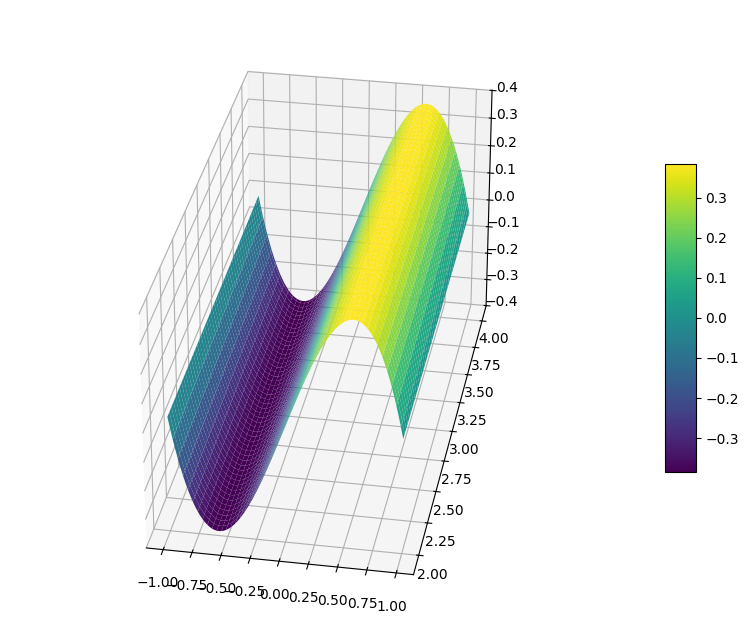

In [ ]:
#Hybrid_x=0_u1

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
y_vals = np.linspace(-1, 1, 100)
p_vals = np.linspace(2, 4, 100)

# 2D 그리드 생성 (y,w)
y_grid, p_grid = np.meshgrid(y_vals, p_vals)

# x=0 고정
x_grid = np.zeros_like(y_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_p_plot = torch.tensor(p_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
#sol_plot = net_2d_1(pt_x_plot, pt_y_plot, pt_p_plot)
#sol_plot = k*pt_y_plot*(1 - pt_x_plot**2 - pt_y_plot**2) - net_2d_1(pt_x_plot, pt_y_plot, pt_p_plot)
sol_plot = k*pt_y_plot*(1 - pt_x_plot**2 - pt_y_plot**2)

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(y_grid, p_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
#ax.set_zlim(-0.01,0.01)
ax.view_init(elev=30, azim=280)
ax.set_box_aspect([1, 2, 1])

plt.show()


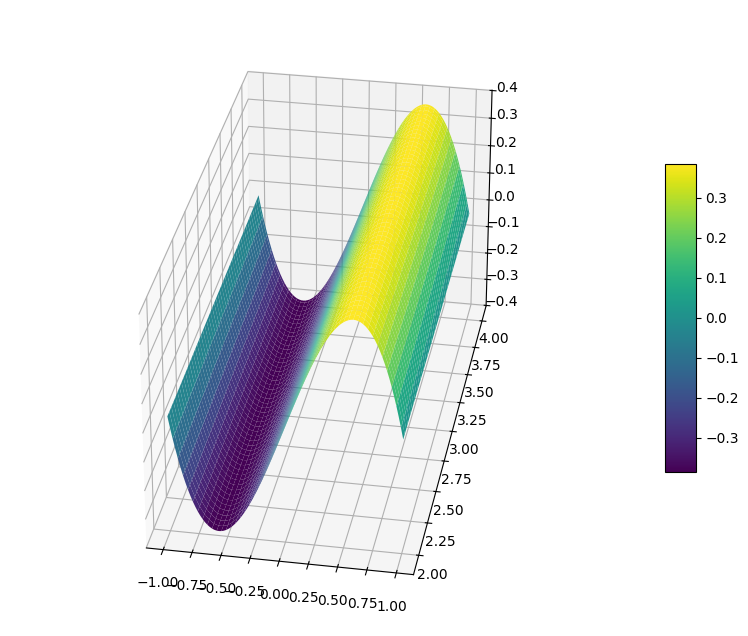

In [ ]:
#PINN_x=0_u1

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
y_vals = np.linspace(-1, 1, 100)      # 원래 코드에서 y 범위 [-1,1]
p_vals = np.linspace(2, 4, 100)     # p 범위 [0.1, 6]

# 2D 그리드 생성 (y,w)
y_grid, p_grid = np.meshgrid(y_vals, p_vals)

# x=0 고정
x_grid = np.zeros_like(y_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_p_plot = torch.tensor(p_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
sol_plot = net_pinn_1(pt_x_plot, pt_y_plot, pt_p_plot)
#sol_plot = k*pt_y_plot*(1 - pt_x_plot**2 - pt_y_plot**2) - net_pinn_1(pt_x_plot, pt_y_plot, pt_p_plot)

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(y_grid, p_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
ax.set_box_aspect([1, 2, 1])
ax.view_init(elev=30, azim=280)
#ax.set_zlim(-0.01,0.01)

plt.show()


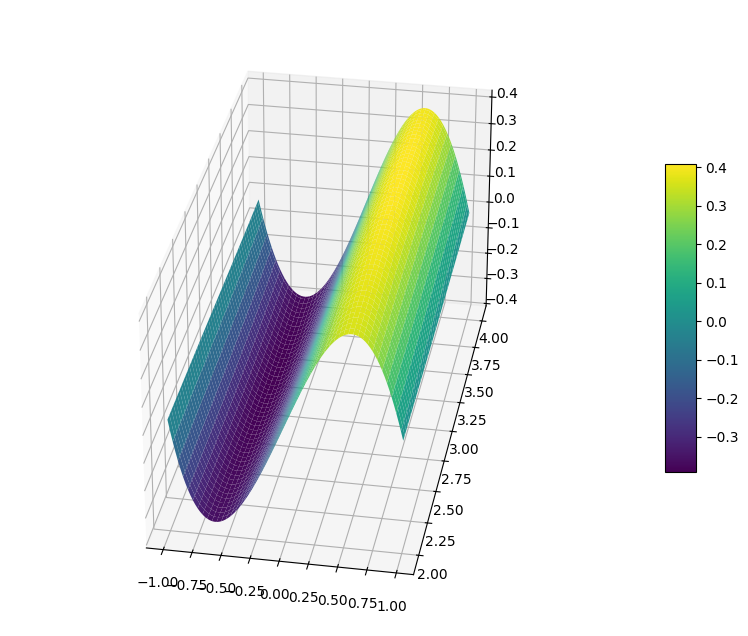

In [ ]:
#DRM_x=0_u1

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
y_vals = np.linspace(-1, 1, 100)      # 원래 코드에서 y 범위 [-1,1]
p_vals = np.linspace(2, 4, 100)     # p 범위 [0.1, 6]

# 2D 그리드 생성 (y,w)
y_grid, p_grid = np.meshgrid(y_vals, p_vals)

# x=0 고정
x_grid = np.zeros_like(y_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_p_plot = torch.tensor(p_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
sol_plot = net_drm_1(pt_x_plot, pt_y_plot, pt_p_plot)
#sol_plot = k*pt_y_plot*(1 - pt_x_plot**2 - pt_y_plot**2) - net_drm_1(pt_x_plot, pt_y_plot, pt_p_plot)

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(y_grid, p_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
ax.set_box_aspect([1, 2, 1])
ax.view_init(elev=30, azim=280)
#ax.set_zlim(-0.01,0.01)

plt.show()


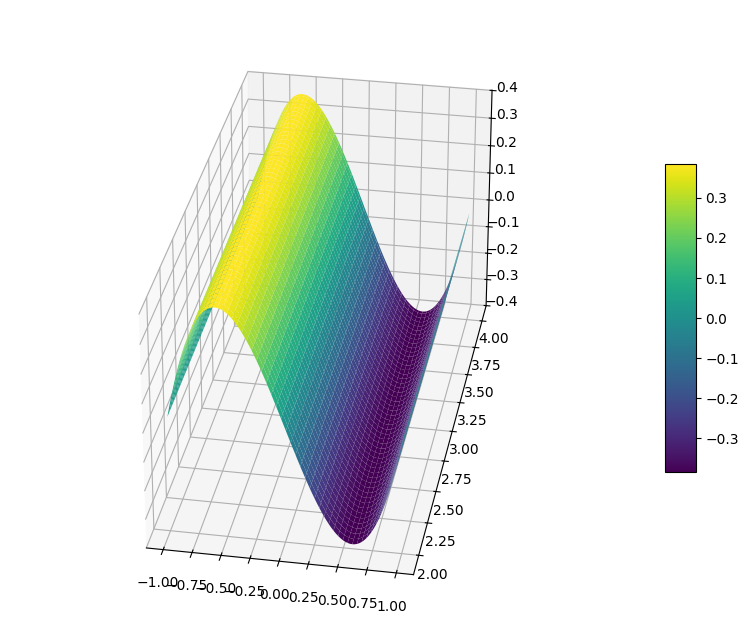

In [ ]:
#Hybrid_y=0_u2

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
x_vals = np.linspace(-1, 1, 100)      # 원래 코드에서 y 범위 [-1,1]
p_vals = np.linspace(2, 4, 100)     # p 범위 [0.1, 6]

# 2D 그리드 생성 (y,w)
x_grid, p_grid = np.meshgrid(x_vals, p_vals)

# x=0 고정
y_grid = np.zeros_like(x_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_p_plot = torch.tensor(p_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
#sol_plot = net_2d_2(pt_x_plot, pt_y_plot, pt_p_plot)
#sol_plot = k*(-pt_x_plot)*(1 - pt_x_plot**2 - pt_y_plot**2) - net_2d_2(pt_x_plot, pt_y_plot, pt_p_plot)
sol_plot = k*(-pt_x_plot)*(1 - pt_x_plot**2 - pt_y_plot**2)

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_grid, p_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
ax.set_box_aspect([1, 2, 1])
ax.view_init(elev=30, azim=280)
#ax.set_zlim(-0.01,0.01)

plt.show()


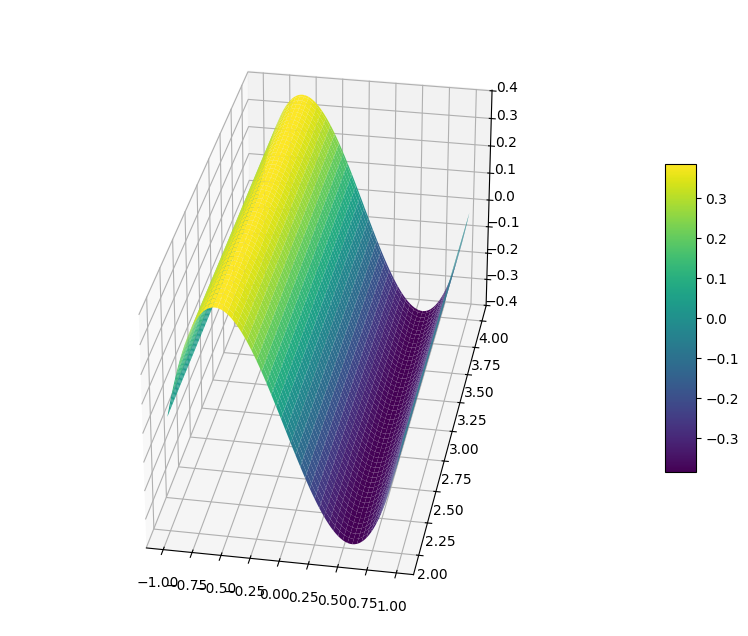

In [ ]:
#PINN_y=0_u2

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
x_vals = np.linspace(-1, 1, 100)      # 원래 코드에서 y 범위 [-1,1]
p_vals = np.linspace(2, 4, 100)     # p 범위 [0.1, 6]

# 2D 그리드 생성 (y,w)
x_grid, p_grid = np.meshgrid(x_vals, p_vals)

# x=0 고정
y_grid = np.zeros_like(x_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_p_plot = torch.tensor(p_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
sol_plot = net_pinn_2(pt_x_plot, pt_y_plot, pt_p_plot)
#sol_plot = k*(-pt_x_plot)*(1 - pt_x_plot**2 - pt_y_plot**2) - net_pinn_2(pt_x_plot, pt_y_plot, pt_p_plot)

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_grid, p_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
ax.set_box_aspect([1, 2, 1])
ax.view_init(elev=30, azim=280)
#ax.set_zlim(-0.01,0.01)

plt.show()


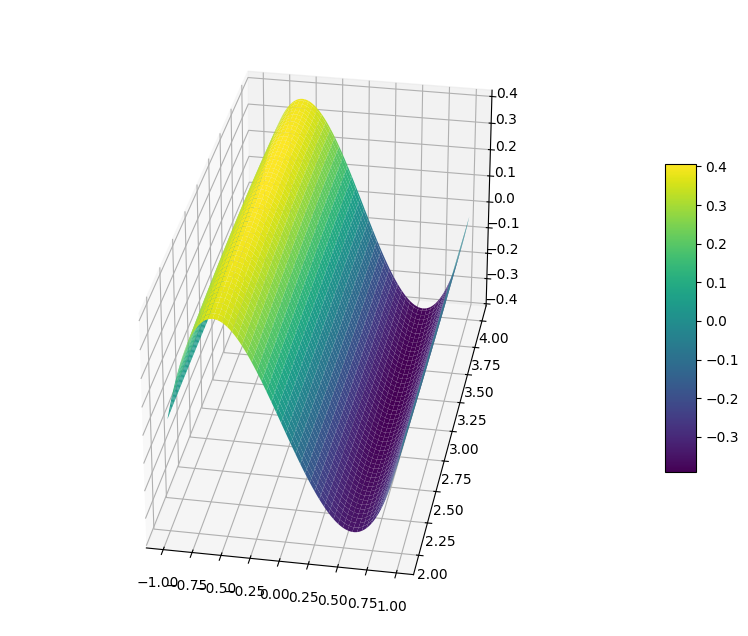

In [ ]:
#DRM_y=0_u2

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
x_vals = np.linspace(-1, 1, 100)      # 원래 코드에서 y 범위 [-1,1]
p_vals = np.linspace(2, 4, 100)     # p 범위 [0.1, 6]

# 2D 그리드 생성 (y,w)
x_grid, p_grid = np.meshgrid(x_vals, p_vals)

# x=0 고정
y_grid = np.zeros_like(x_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_p_plot = torch.tensor(p_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
sol_plot = net_drm_2(pt_x_plot, pt_y_plot, pt_p_plot)
#sol_plot = k*(-pt_x_plot)*(1 - pt_x_plot**2 - pt_y_plot**2) - net_drm_2(pt_x_plot, pt_y_plot, pt_p_plot)

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_grid, p_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
ax.set_box_aspect([1, 2, 1])
ax.view_init(elev=30, azim=280)
#ax.set_zlim(-0.1,0.1)

plt.show()


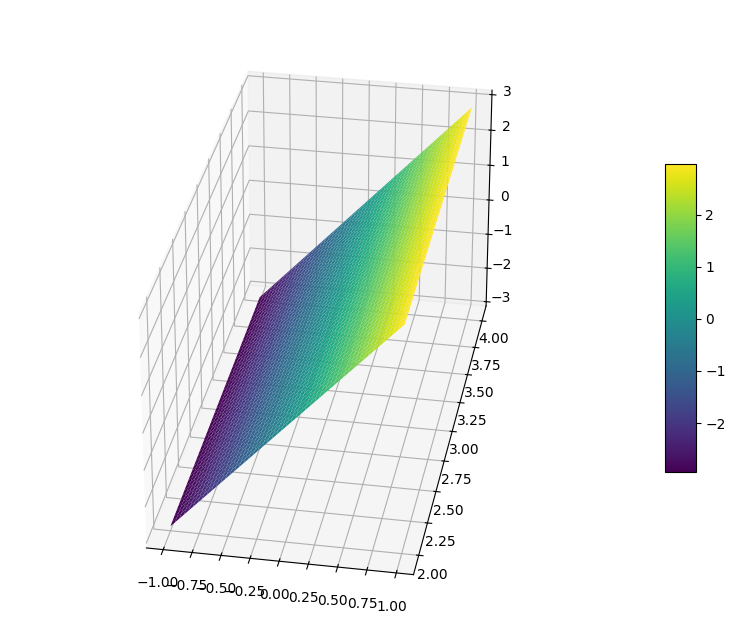

In [ ]:
#Hybrid_x=0_P

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
y_vals = np.linspace(-1, 1, 100)      # 원래 코드에서 y 범위 [-1,1]
p_vals = np.linspace(2, 4, 100)     # p 범위 [0.1, 6]

# 2D 그리드 생성 (y,w)
y_grid, p_grid = np.meshgrid(y_vals, p_vals)

# x=0 고정
x_grid = np.zeros_like(y_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_p_plot = torch.tensor(p_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
#sol_plot = net_2d_P(pt_x_plot, pt_y_plot, pt_p_plot)
#sol_plot = 3*(pt_x_plot + pt_y_plot) - net_2d_P(pt_x_plot, pt_y_plot, pt_p_plot)
sol_plot = 3*(pt_x_plot + pt_y_plot)

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(y_grid, p_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
ax.set_box_aspect([1, 2, 1])
ax.view_init(elev=30, azim=280)
#ax.set_zlim(-0.1,0.1)

plt.show()


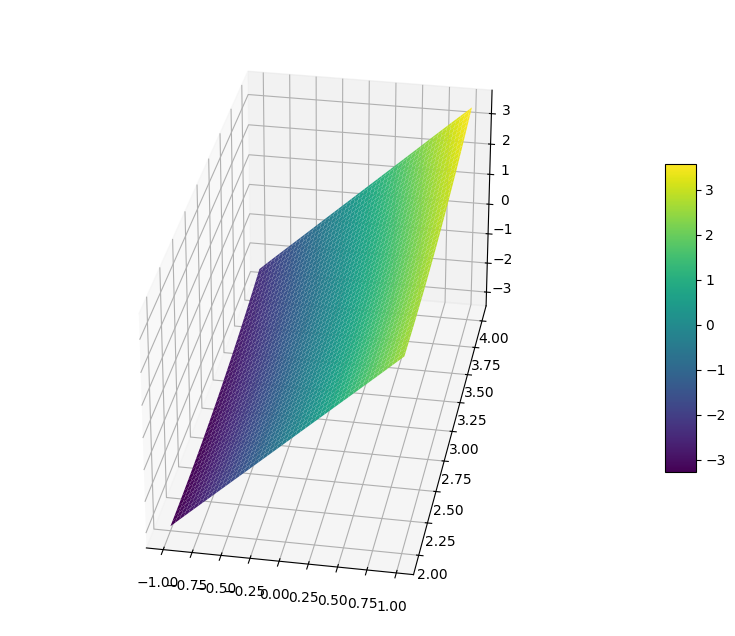

In [ ]:
#PINN_x=0_P

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
y_vals = np.linspace(-1, 1, 100)      # 원래 코드에서 y 범위 [-1,1]
p_vals = np.linspace(2, 4, 100)     # p 범위 [0.1, 6]

# 2D 그리드 생성 (y,w)
y_grid, p_grid = np.meshgrid(y_vals, p_vals)

# x=0 고정
x_grid = np.zeros_like(y_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_p_plot = torch.tensor(p_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
sol_plot = net_pinn_P(pt_x_plot, pt_y_plot, pt_p_plot)
#sol_plot = 3*(pt_x_plot + pt_y_plot) - net_pinn_P(pt_x_plot, pt_y_plot, pt_p_plot)

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(y_grid, p_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
ax.view_init(elev=30, azim=280)
ax.set_box_aspect([1, 2, 1])

plt.show()


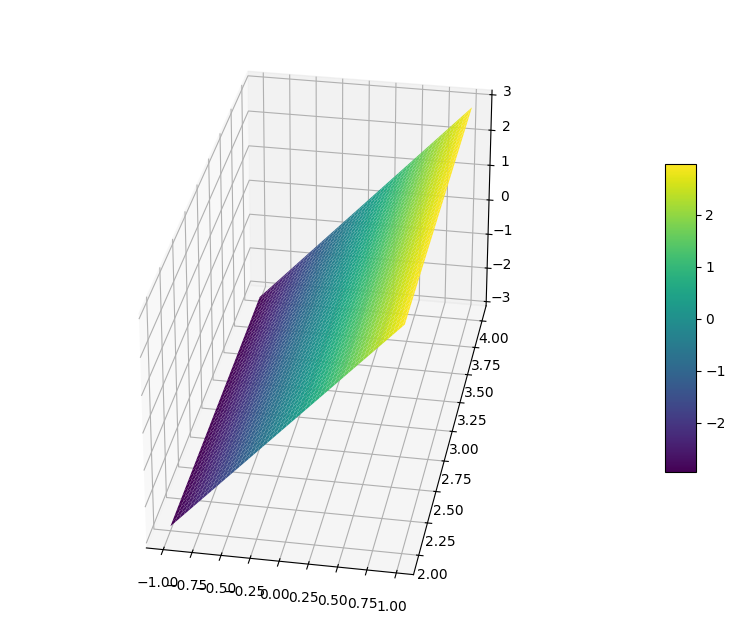

In [ ]:
#DRM_x=0_P

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# y와 w의 범위 설정
y_vals = np.linspace(-1, 1, 100)      # 원래 코드에서 y 범위 [-1,1]
p_vals = np.linspace(2, 4, 100)     # p 범위 [0.1, 6]

# 2D 그리드 생성 (y,w)
y_grid, p_grid = np.meshgrid(y_vals, p_vals)

# x=0 고정
x_grid = np.zeros_like(y_grid)

# torch tensor 변환
pt_x_plot = torch.tensor(x_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_y_plot = torch.tensor(y_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)
pt_p_plot = torch.tensor(p_grid.ravel(), dtype=torch.float32).to(device).view(-1, 1)

# u(x=0,y,w) 계산
#sol_plot = net_drm_P(pt_x_plot, pt_y_plot, pt_p_plot)
sol_plot = 3*(pt_x_plot + pt_y_plot) - net_drm_P(pt_x_plot, pt_y_plot, pt_p_plot)

# 다시 2D grid 형태로 변환
sol_plot_reshaped = sol_plot.detach().cpu().numpy().reshape(y_grid.shape)

# 그래프 그리기
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(y_grid, p_grid, sol_plot_reshaped, cmap='viridis')

# 색상바 추가
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
#cbar.set_label("u(0, y, p)")

# 레이블 설정
#ax.set_xlabel("y")
#ax.set_ylabel("p")
#ax.set_zlabel("u")
#ax.set_title("3D Plot of u(0, y, p)")
ax.view_init(elev=30, azim=280)
ax.set_box_aspect([1, 2, 1])
#ax.set_zlim(-0.1,0.1)

plt.show()


# Comparing Error Curves

Errors for u1

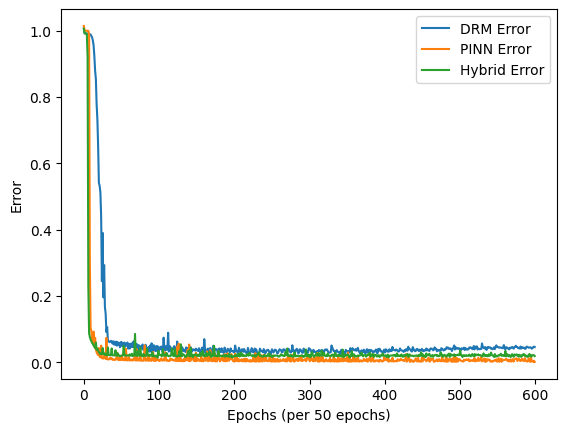

In [ ]:
import matplotlib.pyplot as plt

plt.plot(error_drm_list1, label='DRM Error')
plt.plot(error_pinn_list1, label='PINN Error')
plt.plot(error_list1, label='Hybrid Error')

#plt.title('DRM for parametric stokes equation')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')
#plt.yscale('log')

plt.legend()

plt.show()

Error for u2

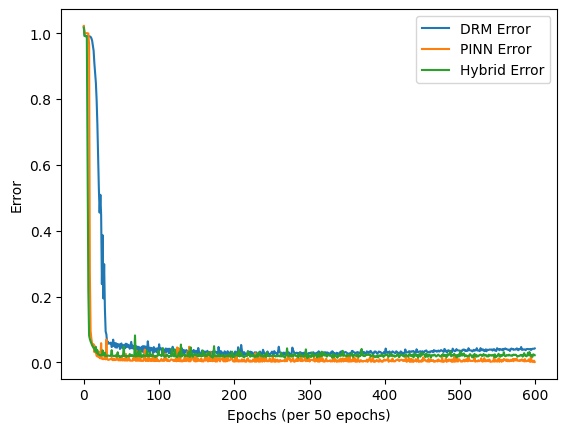

In [ ]:
import matplotlib.pyplot as plt

plt.plot(error_drm_list2, label='DRM Error')
plt.plot(error_pinn_list2, label='PINN Error')
plt.plot(error_list2, label='Hybrid Error')

#plt.title('DRM for parametric stokes equation')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')
#plt.yscale('log')

plt.legend()

plt.show()

Errors for P

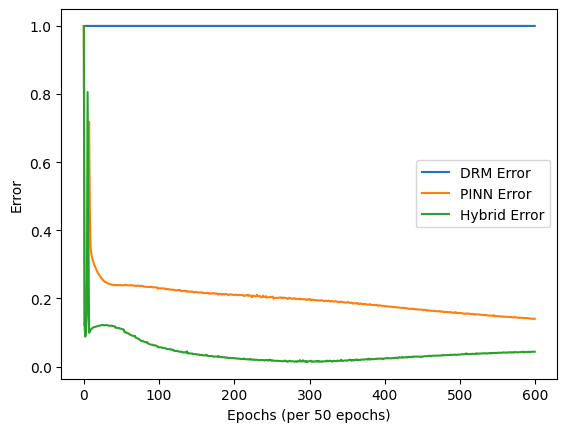

In [ ]:
import matplotlib.pyplot as plt

plt.plot(error_drm_list3, label='DRM Error')
plt.plot(error_pinn_list3, label='PINN Error')
plt.plot(error_list3, label='Hybrid Error')

#plt.title('DRM for parametric stokes equation')
plt.xlabel('Epochs (per 50 epochs)')
plt.ylabel('Error')
#plt.yscale('log')

plt.legend()

plt.show()